In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (confusion_matrix,classification_report, ConfusionMatrixDisplay)

In [ ]:
df=pd.read_csv("train_u6lujuX_CVtuZ9i.csv")
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.shape

(614, 13)

In [ ]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [ ]:
df.drop("Loan_ID",inplace=True,axis=1)

In [ ]:
df.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [ ]:
numerical_df = df.select_dtypes(include=["int64","float64"]).columns
categorical_df = df.select_dtypes(include=["object"]).columns

/tmp/ipykernel_3951/2256997483.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[columns]) # Changed numerical_df[columns] to df[columns]
/tmp/ipykernel_3951/2256997483.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[columns]) # Changed numerical_df[columns] to df[columns]
/tmp/ipyke

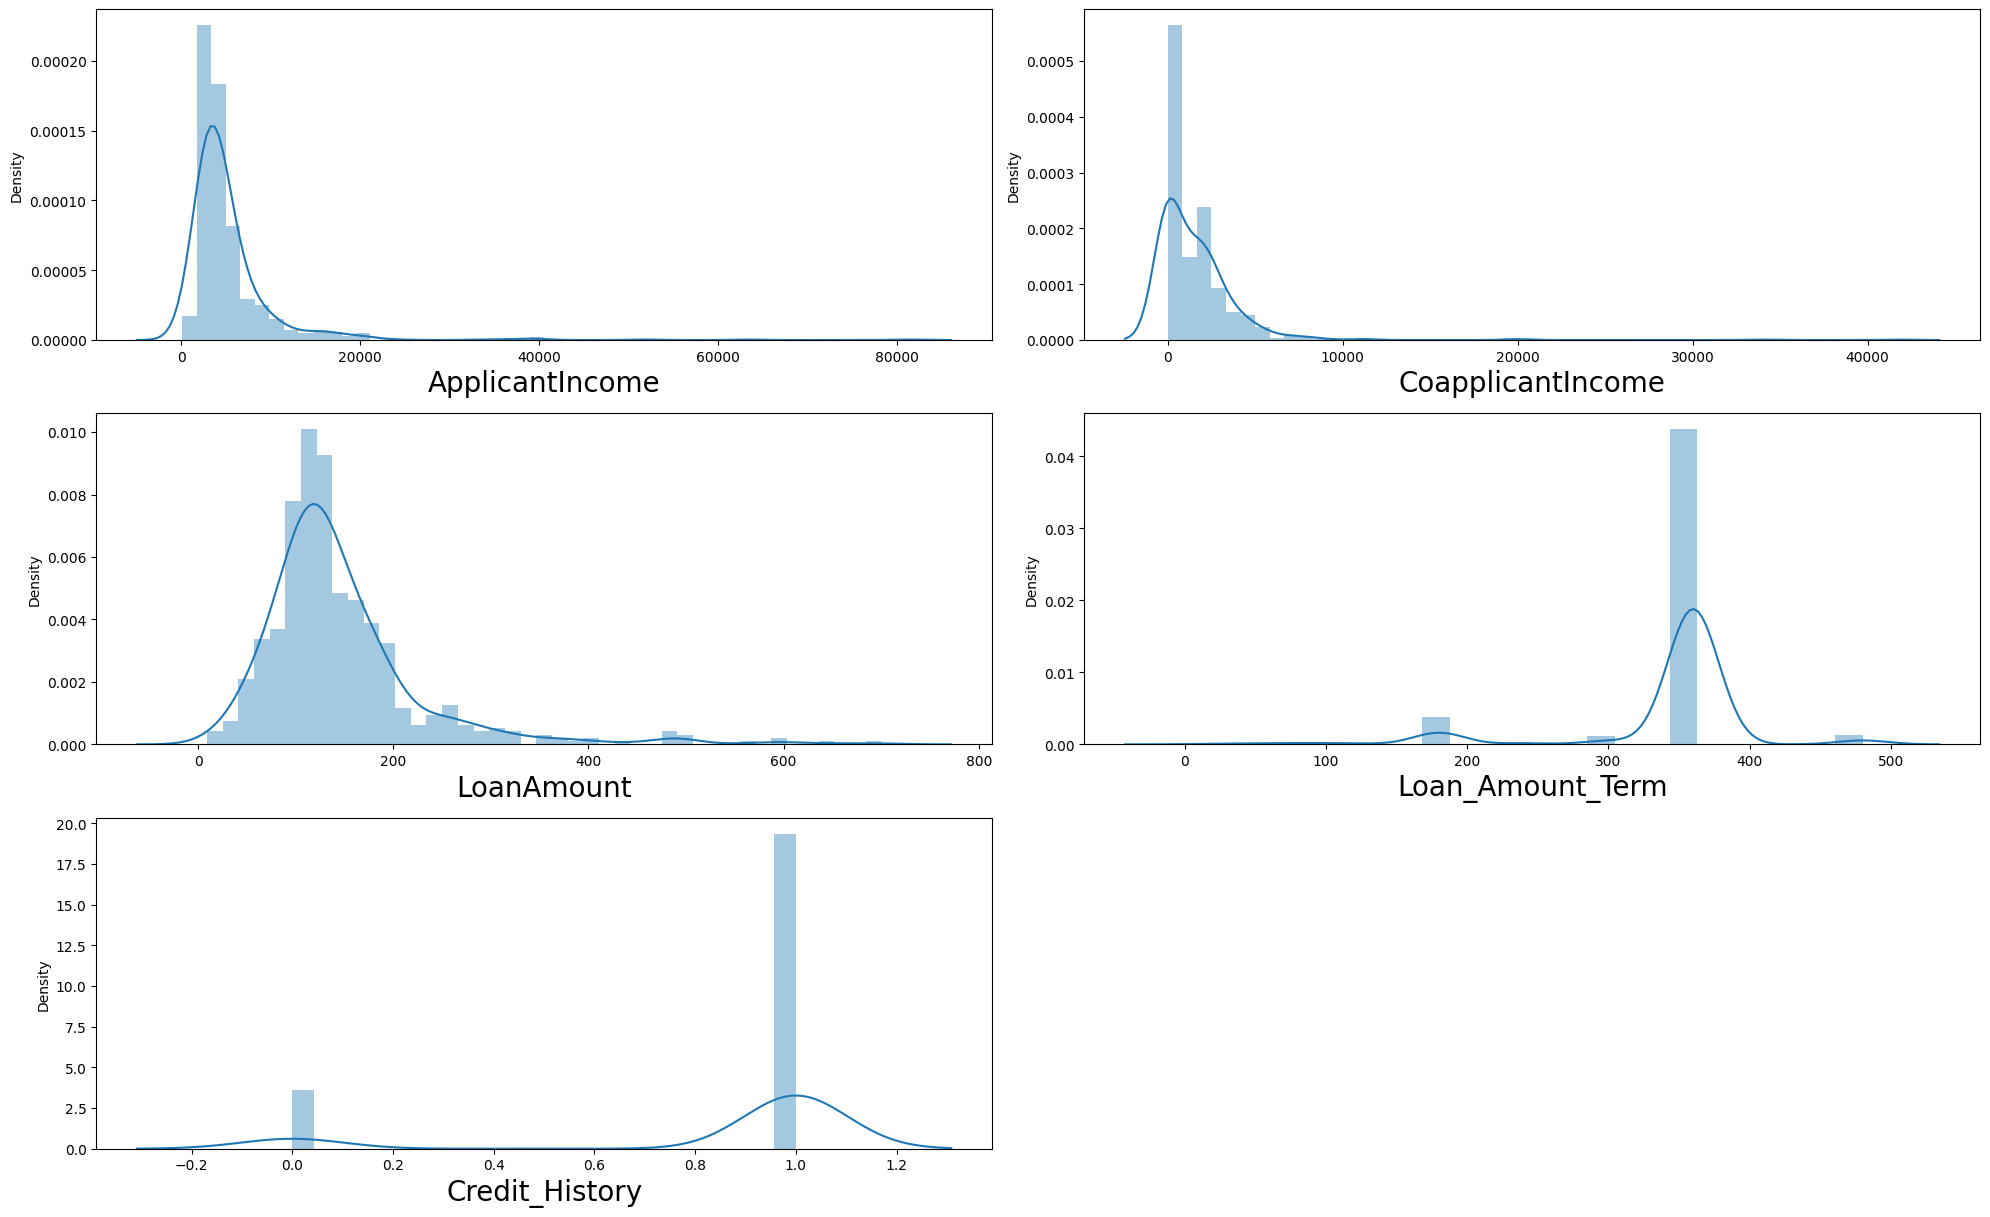

In [ ]:
plt.figure(figsize=(20,40))
plotnum = 1
for columns in numerical_df:
    if plotnum <= len(numerical_df) : # Changed numerical_df.columns to numerical_df
        ax=plt.subplot(10,2,plotnum)
        sns.distplot(df[columns]) # Changed numerical_df[columns] to df[columns]
        plt.xlabel(columns,fontsize=20)
    plotnum += 1
plt.tight_layout()
plt.show()

In [ ]:
for col in numerical_df:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
for col in categorical_df:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    summary.append({
        "Feature": col,
        "Outliers": len(outliers)
    })

outlier_df = pd.DataFrame(summary)
print(outlier_df)

             Feature  Outliers
0    ApplicantIncome        50
1  CoapplicantIncome        18
2         LoanAmount        41
3   Loan_Amount_Term        88
4     Credit_History        89


In [ ]:
# =========================================
# DESCRIPTIVE STATISTICS FOR
# CATEGORICAL FEATURES
# =========================================

import pandas as pd

# Select categorical columns
categorical_cols = df.select_dtypes(include='object').columns

summary = []

# Loop through each categorical variable
for col in categorical_cols:

    counts = df[col].value_counts()

    percentages = (df[col].value_counts(normalize=True) * 100)

    # Store results
    for category in counts.index:

        summary.append({
            "Variable": col,
            "Category": category,
            "Count": counts[category],
            "Percentage": f"{percentages[category]:.2f}%"
        })

# Create dataframe
categorical_summary = pd.DataFrame(summary)

# Display output
print("Descriptive statistics for categorical features\n")

print(categorical_summary)

Descriptive statistics for categorical features

         Variable      Category  Count Percentage
0          Gender          Male    502     81.76%
1          Gender        Female    112     18.24%
2         Married           Yes    401     65.31%
3         Married            No    213     34.69%
4      Dependents             0    360     58.63%
5      Dependents             1    102     16.61%
6      Dependents             2    101     16.45%
7      Dependents            3+     51      8.31%
8       Education      Graduate    480     78.18%
9       Education  Not Graduate    134     21.82%
10  Self_Employed            No    532     86.64%
11  Self_Employed           Yes     82     13.36%
12  Property_Area     Semiurban    233     37.95%
13  Property_Area         Urban    202     32.90%
14  Property_Area         Rural    179     29.15%
15    Loan_Status             Y    422     68.73%
16    Loan_Status             N    192     31.27%


In [ ]:
# Professional soft academic theme
sns.set_style("whitegrid")

main_colors = [
    "#193882",
    "#2C4EA3",
    "#1E5AA8",
    "#4A86E8",
    "#D6E4FF"
]

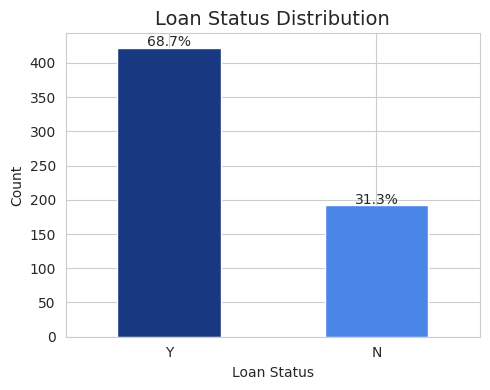

In [ ]:
plt.figure(figsize=(5,4))

# Value counts
counts = df['Loan_Status'].value_counts()

total = counts.sum()

percentages = (counts / total) * 100

# Plot
bars = counts.plot(
    kind='bar',
    color=[main_colors[0], main_colors[3]]
)

# Add percentages
for i, (count, pct) in enumerate(zip(counts, percentages)):

    plt.text(
        i,
        count + 2,
        f'{pct:.1f}%',
        ha='center',
        fontsize=10
    )

plt.title("Loan Status Distribution", fontsize=14)

plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

/tmp/ipykernel_3951/4254664193.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


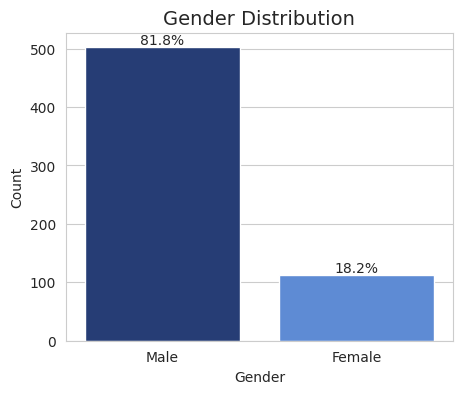

In [ ]:
plt.figure(figsize=(5,4))

ax = sns.countplot(
    x='Gender',
    data=df,
    palette= ["#193882","#4A86E8"]
)

# Add percentages
total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'

    ax.annotate(
        percentage,
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Gender Distribution", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()


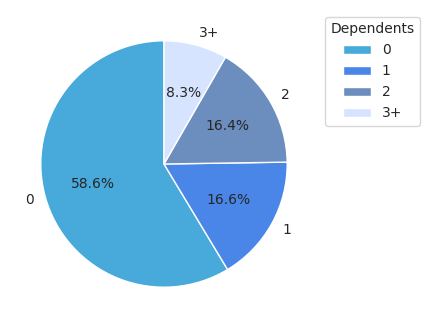

In [ ]:
dependents = df['Dependents'].value_counts()

colors = [
    "#48AADA",
    "#4A86E8",
    "#6C8EBF",
    "#D6E4FF"
]

plt.figure(figsize=(5,4))

plt.pie(
    dependents.values,
    labels=dependents.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.legend(
    title="Dependents",
    bbox_to_anchor=(1, 1)
)

#plt.title("Dependents Distribution")

plt.show()

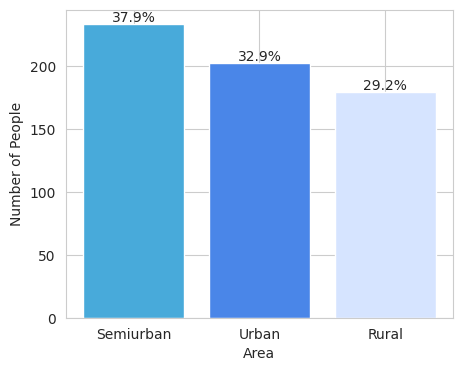

In [ ]:
total = df["Property_Area"].value_counts().sum()
percentages = (df["Property_Area"].value_counts() / total) * 100

plt.figure(figsize=(5, 4))

bars = plt.bar(df["Property_Area"].value_counts().index, df["Property_Area"].value_counts().values,color=['#48AADA', main_colors[3],main_colors[4]],
    edgecolor='white' )

#plt.title("Property Area")
plt.xlabel("Area")
plt.ylabel("Number of People")

# Add percentage labels on bars
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{pct:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

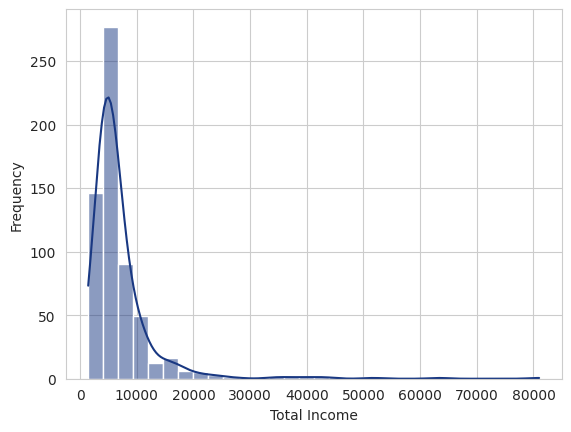

In [ ]:
sns.histplot(df['TotalIncome'], bins=30, kde=True, color=main_colors[0],
    edgecolor='white')
#plt.title("Distribution of Total Income")
plt.xlabel("Total Income")
plt.ylabel("Frequency")
plt.show()

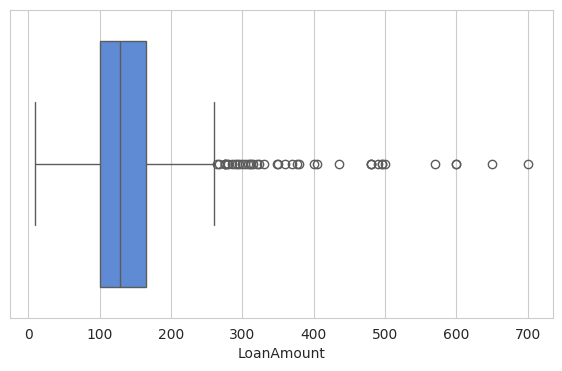

In [ ]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x=df['LoanAmount'],
    color=main_colors[3]
)

#plt.title("Boxplot of Loan Amount", fontsize=14)

plt.show()

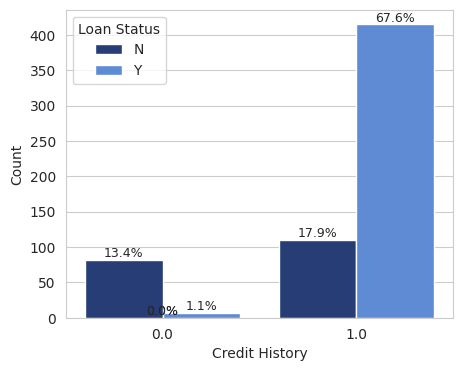

In [ ]:
plt.figure(figsize=(5,4))

ax = sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data=df,
    palette=["#193882","#4A86E8"]
)

# Add percentages
total = len(df)

for p in ax.patches:

    percentage = f'{100 * p.get_height()/total:.1f}%'

    ax.annotate(
        percentage,
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

#plt.title("Credit History vs Loan Status", fontsize=14)
plt.xlabel("Credit History")
plt.ylabel("Count")

plt.legend(title="Loan Status")

plt.show()


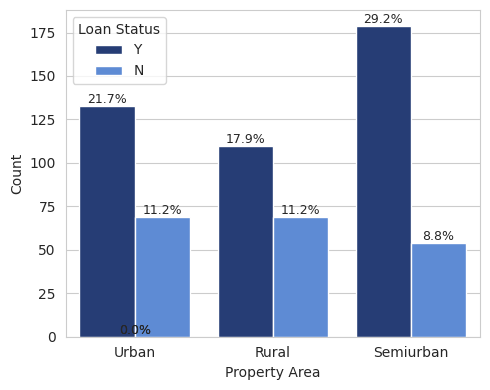

In [ ]:
# =========================================
# PROPERTY AREA VS LOAN STATUS
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Soft academic color palette
colors = ["#193882","#4A86E8"]

plt.figure(figsize=(5,4))

ax = sns.countplot(
    x='Property_Area',
    hue='Loan_Status',
    data=df,
    palette=colors
)

# Add percentages
total = len(df)

for p in ax.patches:

    percentage = f'{100 * p.get_height() / total:.1f}%'

    ax.annotate(
        percentage,
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

#plt.title("Property Area vs Loan Status", fontsize=14)
plt.xlabel("Property Area")
plt.ylabel("Count")

plt.legend(title="Loan Status")

plt.tight_layout()
plt.show()

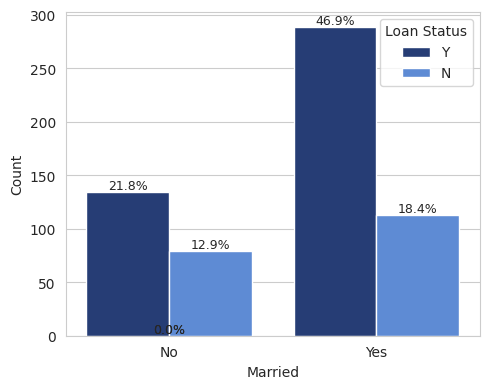

In [ ]:
# =========================================
# MARRIED VS LOAN STATUS
# =========================================

plt.figure(figsize=(5,4))

ax = sns.countplot(
    x='Married',
    hue='Loan_Status',
    data=df,
    palette=colors
)

# Add percentages
total = len(df)

for p in ax.patches:

    percentage = f'{100 * p.get_height() / total:.1f}%'

    ax.annotate(
        percentage,
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

#plt.title("Marital Status vs Loan Status", fontsize=14)
plt.xlabel("Married")
plt.ylabel("Count")

plt.legend(title="Loan Status")

plt.tight_layout()
plt.show()

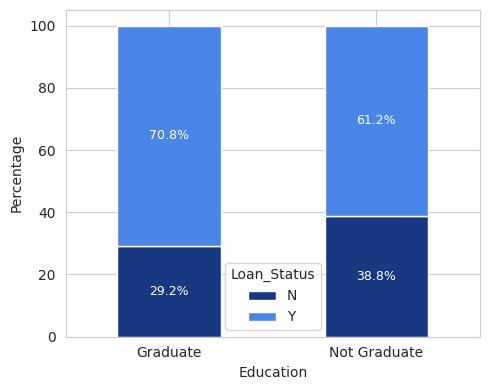

In [ ]:


# Crosstab and convert to %
data = pd.crosstab(df["Education"], df["Loan_Status"])
data_percent = data.div(data.sum(axis=1), axis=0) * 100

ax = data_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(5, 4),
    color=[main_colors[0],main_colors[3]]
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",   # INSIDE bars (best look)
        fontsize=9,
        color="white"
    )

#plt.title("Education vs Loan Status (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Loan_Status")
plt.tight_layout()
plt.show()

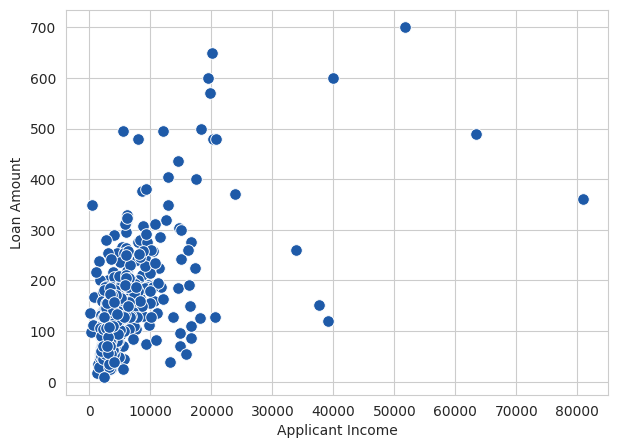

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='ApplicantIncome',
    y='LoanAmount',
    data=df,
    color=main_colors[2],
    s=70
)

#plt.title("Applicant Income vs Loan Amount", fontsize=14)
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")

plt.show()

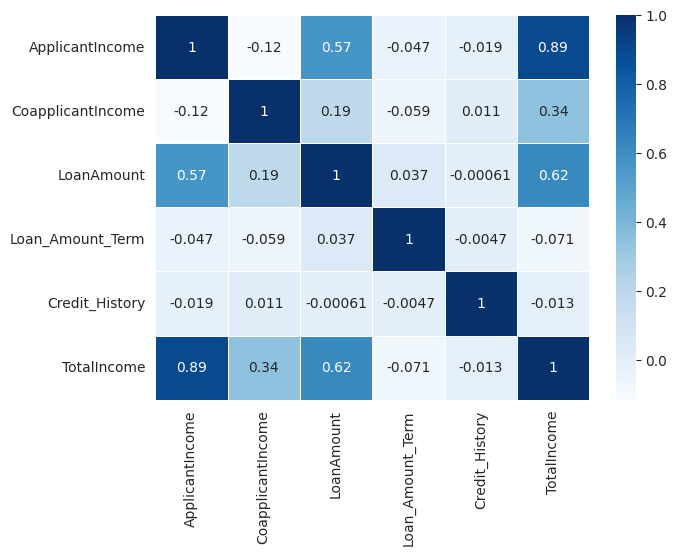

In [ ]:
plt.figure(figsize=(7,5))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    linewidths=0.5
)

#plt.title("Correlation Heatmap", fontsize=15)

plt.show()

In [ ]:

# -----------------------------------------
# HANDLE DEPENDENTS
# -----------------------------------------

df['Dependents'] = df['Dependents'].replace('3+', 3)

df['Dependents'] = df['Dependents'].astype(int)

df["Credit_History"] = df["Credit_History"].astype(int)
# -----------------------------------------
# LABEL ENCODING
# -----------------------------------------

binary_cols = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Loan_Status'
]

encoders = {}

for col in binary_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encoders[col] = le

# -----------------------------------------
# ONE-HOT ENCODING
# -----------------------------------------

df = pd.get_dummies(
    df,
    columns=['Property_Area'],
    drop_first=True
)

In [ ]:
df.dtypes

,0
Gender,int64
Married,int64
Dependents,int64
Education,int64
Self_Employed,int64
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,int64


In [ ]:
summary_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Unique Values': df.nunique()
})

summary_df

,Data Type,Unique Values
Gender,int64,2
Married,int64,2
Dependents,int64,4
Education,int64,2
Self_Employed,int64,2
ApplicantIncome,int64,505
CoapplicantIncome,float64,287
LoanAmount,float64,203
Loan_Amount_Term,float64,10
Credit_History,int64,2


In [ ]:
df.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849,0.0,128.0,360.0,1,1,5849.0,False,True
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1,0,6091.0,False,False
2,1,1,0,0,1,3000,0.0,66.0,360.0,1,1,3000.0,False,True
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1,1,4941.0,False,True
4,1,0,0,0,0,6000,0.0,141.0,360.0,1,1,6000.0,False,True
5,1,1,2,0,1,5417,4196.0,267.0,360.0,1,1,9613.0,False,True
6,1,1,0,1,0,2333,1516.0,95.0,360.0,1,1,3849.0,False,True
7,1,1,3,0,0,3036,2504.0,158.0,360.0,0,0,5540.0,True,False
8,1,1,2,0,0,4006,1526.0,168.0,360.0,1,1,5532.0,False,True
9,1,1,1,0,0,12841,10968.0,349.0,360.0,1,0,23809.0,True,False


In [ ]:
X = df.drop(columns=["Loan_Status"], axis=1)
y = df["Loan_Status"]

In [ ]:
df.shape

(614, 14)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
models = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "C": [0.1, 1, 10],
            "penalty": ["l2"]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [None, 5, 10]
        }

    },
    "GradientBoosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100],
            "learning_rate": [0.05, 0.1]
        }
    },
    "DecisionTree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [None, 5, 10]
        }
    },
   "SVM": {
        "model": SVC(probability=True),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"]
        }
   }
}

In [ ]:
results = []

best_f1 = 0
best_model = None

for name, info in models.items():

    grid = GridSearchCV(
        estimator=info["model"],
        param_grid=info["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    # Models needing scaling
    if name in ["LogisticRegression", "SVM"]:

        grid.fit(X_train_scaled, y_train)

        current_model = grid.best_estimator_

        y_pred = current_model.predict(X_test_scaled)

        y_prob = current_model.predict_proba(X_test_scaled)[:,1]

    else:

        grid.fit(X_train, y_train)

        current_model = grid.best_estimator_

        y_pred = current_model.predict(X_test)

        y_prob = current_model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    # Save results
    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Accuracy": accuracy,
        "F1-Score": f1,
        "AUC": auc
    })

    # Save best model
    if f1 > best_f1:
        best_f1 = f1
        best_model = current_model
        best_model_name = name

# Results table
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

print(results_df)

print("\nBest Model:", best_model_name)

                Model                                  Best Params  Accuracy  \
0  LogisticRegression                  {'C': 0.1, 'penalty': 'l2'}  0.861789   
3        DecisionTree                             {'max_depth': 5}  0.861789   
4                 SVM               {'C': 0.1, 'kernel': 'linear'}  0.853659   
1        RandomForest        {'max_depth': 5, 'n_estimators': 100}  0.845528   
2    GradientBoosting  {'learning_rate': 0.05, 'n_estimators': 50}  0.837398   

   F1-Score       AUC  
0  0.908108  0.847678  
3  0.907104  0.783746  
4  0.903226  0.713932  
1  0.897297  0.838390  
2  0.891304  0.816718  

Best Model: LogisticRegression


In [ ]:
# =========================================
# GET BEST MODEL INFO
# =========================================

best_model_info = results_df.iloc[0]

print("Best Model:", best_model_info["Model"])

print("Best Params:", best_model_info["Best Params"])

Best Model: LogisticRegression
Best Params: {'C': 0.1, 'penalty': 'l2'}


In [ ]:
# -----------------------------------------

best_name = best_model_info["Model"]

best_params = best_model_info["Best Params"]

In [ ]:
# =========================================
# REBUILD BEST MODEL
# =========================================

best_model = models[best_name]["model"]

best_model.set_params(**best_params)


LogisticRegression(C=0.1, max_iter=1000)

In [ ]:
# =========================================
# TRAIN MODEL
# =========================================

if best_name in ["LogisticRegression", "SVM"]:

    best_model.fit(X_train_scaled, y_train)

    y_pred = best_model.predict(X_test_scaled)

else:

    best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)

In [ ]:
# =========================================
# CLASSIFICATION REPORT
# =========================================

from sklearn.metrics import classification_report

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



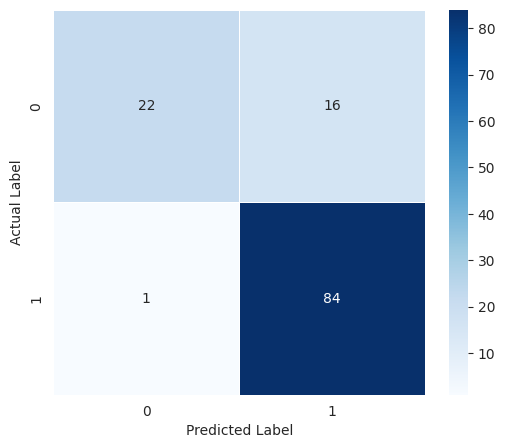

In [ ]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

#plt.title("Confusion Matrix - Best Model")

plt.show()

In [ ]:
# =========================================
# FEATURE IMPORTANCE
# ONLY FOR LOGISTIC REGRESSION
# =========================================

if best_name == "LogisticRegression":

    # Create dataframe
    feature_importance = pd.DataFrame({

        "Feature": X_train.columns,

        "Coefficient": best_model.coef_[0]

    })

    # Absolute values
    feature_importance["Abs_Coefficient"] = (
        feature_importance["Coefficient"].abs()
    )

    # Sort
    feature_importance = feature_importance.sort_values(
        "Abs_Coefficient",
        ascending=True
    )

    print(feature_importance)

                    Feature  Coefficient  Abs_Coefficient
8          Loan_Amount_Term    -0.001106         0.001106
5           ApplicantIncome     0.018141         0.018141
7                LoanAmount    -0.029467         0.029467
10              TotalIncome    -0.030464         0.030464
12      Property_Area_Urban     0.034361         0.034361
0                    Gender    -0.050519         0.050519
4             Self_Employed    -0.065096         0.065096
2                Dependents     0.087923         0.087923
6         CoapplicantIncome    -0.115089         0.115089
3                 Education    -0.150966         0.150966
1                   Married     0.215126         0.215126
11  Property_Area_Semiurban     0.304096         0.304096
9            Credit_History     1.049362         1.049362


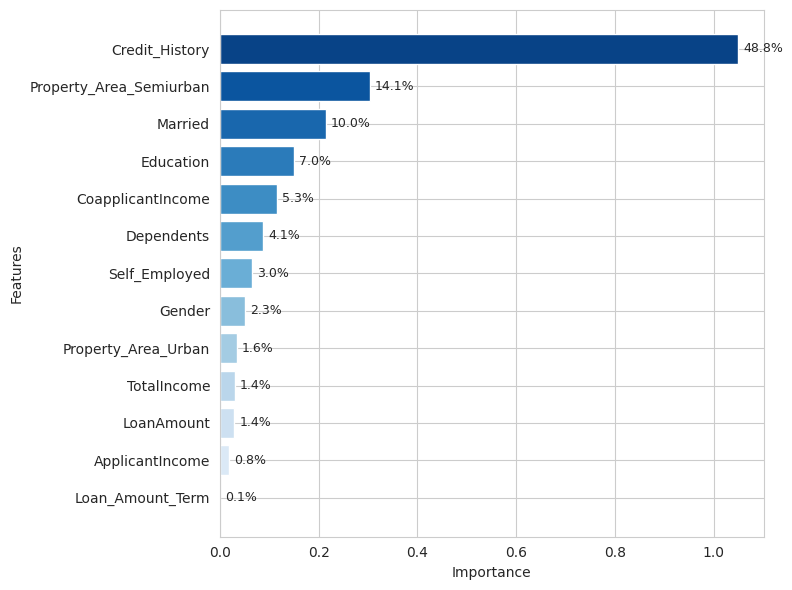

In [ ]:
# -------------------------------------
# FEATURE IMPORTANCE CHART
# -------------------------------------

plt.figure(figsize=(8,6))

fade_colors = sns.color_palette(
    "Blues",
    len(feature_importance)
)

bars = plt.barh(
    feature_importance["Feature"],
    feature_importance["Abs_Coefficient"],
    color=fade_colors
)

# -------------------------------------
# ADD PERCENTAGE LABELS
# -------------------------------------

total = feature_importance["Abs_Coefficient"].sum()

for bar in bars:

    width = bar.get_width()

    percentage = (width / total) * 100

    plt.text(
        width + 0.01,                 # position to right of bar
        bar.get_y() + bar.get_height()/2,
        f"{percentage:.1f}%",
        va='center',
        fontsize=9
    )

#plt.title("Feature Importance")

plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()

plt.show()

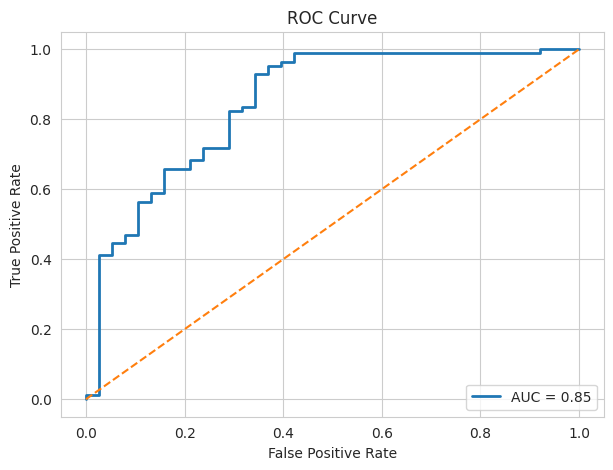

In [ ]:
# =========================================
# ROC CURVE
# =========================================

from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities

if best_name in ["LogisticRegression", "SVM"]:

    y_prob = best_model.predict_proba(X_test_scaled)[:,1]

else:

    y_prob = best_model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}"
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

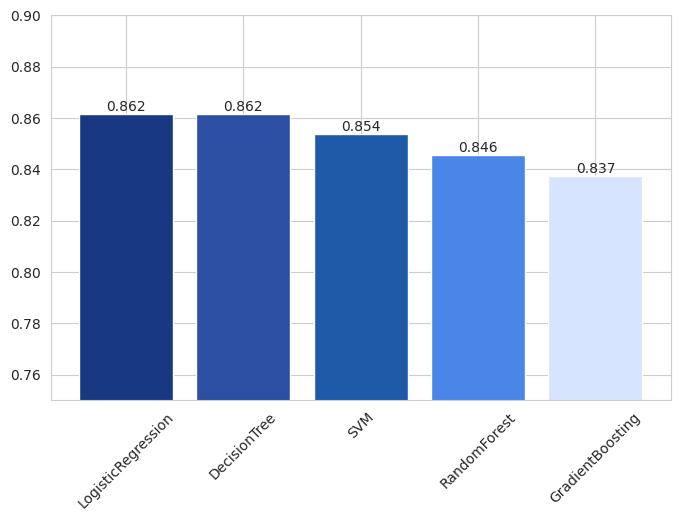

In [ ]:
plt.figure(figsize=(8,5))


bars = plt.bar(results_df["Model"], results_df["Accuracy"], color=[
    "#193882",
    "#2C4EA3",
    "#1E5AA8",
    "#4A86E8",
    "#D6E4FF"
])

#plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylim(0.75, 0.90)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha='center',
        va='bottom'
    )

plt.show()